This notebook uses this [USA Airports Dataset](https://www.kaggle.com/datasets/flashgordon/usa-airport-dataset) from Kaggle.

In [70]:
import pandas as pd
import duckdb

In [73]:
con = duckdb.connect()

In [74]:
describe_query = """
DESCRIBE 'Data/Airports2.csv';
"""

In [123]:
col_names = con.execute(describe_query).df()[['column_name', 'column_type']]
col_names

,column_name,column_type
0,Origin_airport,VARCHAR
1,Destination_airport,VARCHAR
2,Origin_city,VARCHAR
3,Destination_city,VARCHAR
4,Passengers,BIGINT
5,Seats,BIGINT
6,Flights,BIGINT
7,Distance,BIGINT
8,Fly_date,DATE
9,Origin_population,BIGINT


In [118]:
total_number_flights_query = """
SELECT Origin_airport, 
COUNT() AS Count
FROM 'Data/Airports2.csv'
GROUP BY Origin_airport
ORDER BY Count Desc
"""

In [121]:
total_number_flights = con.execute(total_number_flights_query).df()
total_number_flights

,Origin_airport,Count
0,ORD,158496
1,ATL,131046
2,DFW,106698
3,DTW,99624
4,MSP,98922
...,...,...
678,LWF,1
679,HBG,1
680,CUB,1
681,RID,1


In [ ]:
total_flights_all_time = """
SELECT Fly_date,
COUNT() AS Count
FROM 'Data/Airports2.csv'
GROUP BY Fly_Date
"""

In [172]:
total_flights_all_time_df = con.execute(total_flights_all_time).df()


<Axes: xlabel='Fly_date'>

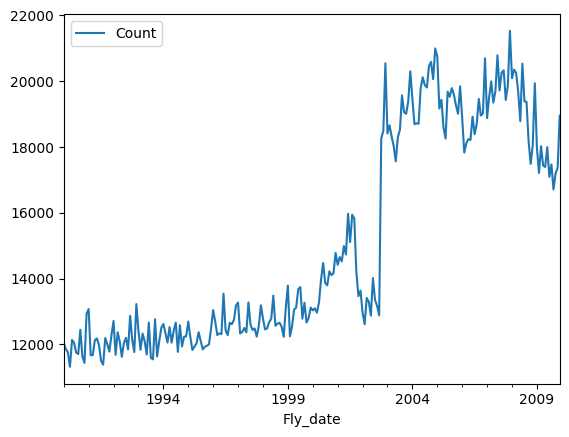

In [173]:
total_flights_all_time_df.set_index('Fly_date').sort_values(by='Fly_date').plot()

Here we can see flying inside the US started to take off in the 2000s. You can see a sharp drop where 9/11 took place, then a massive rise in 03.

In [199]:
flights_one_year = """
SELECT Fly_date,
COUNT() AS Count
FROM 'Data/Airports2.csv'
WHERE Fly_date > '2007-12-31' AND Fly_date < '2009-01-01'
GROUP BY Fly_Date
"""

In [200]:
flights_one_year_df= con.execute(flights_one_year).df().set_index('Fly_date').sort_values(by='Fly_date')


<Axes: xlabel='Fly_date'>

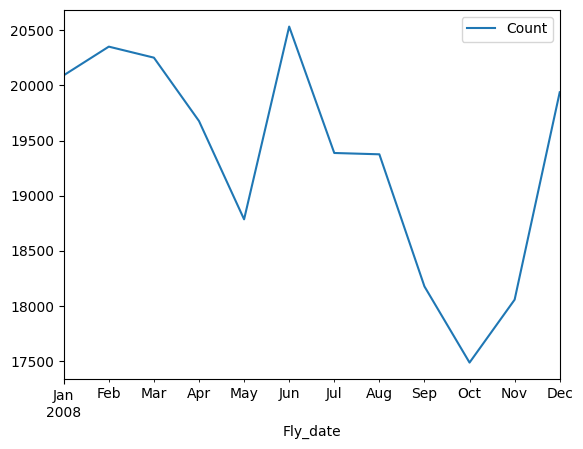

In [201]:
flights_one_year_df.plot()

Although this data is pre 2009 we can still see an influx of travel around the holidays. Mainly around the winter and summer holidays. Here we see in 2008 October a reduced amount of travel compared to toher months.